In [1]:
!sudo apt-get update -y
!sudo apt-get install python3.10 python3.10-dev python3.10-venv –y

!sudo update-alternatives --install /usr/bin/python3 python3 /usr/bin/python3.10 1
!sudo update-alternatives --install /usr/bin/python3 python3 /usr/bin/python3.12 2
!sudo update-alternatives --config python3

!sudo apt-get install python3-pip -y
!python3 -m pip install --upgrade pip

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://cli.github.com/packages stable InRelease [3,917 B]
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:9 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [83.8 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease [24.3 kB]
Get:12 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:13 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jam

In [2]:
!pip install opencv-python \
matplotlib \
numpy \
pandas \
seaborn \
scikit-learn \
Pillow \
tensorflow \
openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 52.7 MB/s  0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 190.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 213.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 209.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 210.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 199.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.4/620.4 MB 16.8 MB/s  0:00:19
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 102.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 116.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 124.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 118.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 144.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 114.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
import glob
from pathlib import Path
import shutil
import time
from random import sample
import uuid
import concurrent.futures
from functools import partial
import re
from collections import defaultdict, Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.utils import compute_class_weight
from sklearn.model_selection import train_test_split, GroupShuffleSplit
import cv2
import tensorflow as tf

# tf.keras.mixed_precision.set_global_policy('mixed_float16')

print(tf.__version__)


2.19.0


In [5]:
class Config:
    # Project paths
    try:
        import google.colab
        PROJECT_ROOT = Path('/content/drive/MyDrive/Colab Notebooks')
        CACHE_DIR = Path("/content/cache")
    except ImportError:
        # Fallback for non-Colab environments where __file__ might be defined
        # or for local development. We need a way to get the current script's path.
        # If running in a local script, __file__ would be defined.
        # If running in a local interactive environment where __file__ isn't defined,
        # we might need to assume the current working directory.
        if '__file__' in locals() or '__file__' in globals():
            PROJECT_ROOT = Path(__file__).parent.resolve()
        else:
            PROJECT_ROOT = Path(os.getcwd())

        CACHE_DIR = PROJECT_ROOT / "cache" / "odir5k_multi_label_classification"

    DATASET_DIR = PROJECT_ROOT / "ODIR-5K"

    # Dataset configuration
    ANNOTATION_FILE_NAME = 'ODIR-5K_Training_Annotations(Updated)_V2.xlsx'
    TRAINING_SOURCE_PATH = 'ODIR-5K_Training_Images/'
    TESTING_SOURCE_PATH = 'ODIR-5K_Testing_Images/'
    LABELS = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
    VALIDATION_FRACTION = 0.1

    # Image processing
    TARGET_SIZE = (512, 512)
    COLOR_MODE = 'rgb'
    COLOR_SHAPE_MAP = {'grayscale': (1,), 'rgb': (3,), 'rgba': (4,)}
    SHAPE_ADD = COLOR_SHAPE_MAP.get(COLOR_MODE, (3,))

    # Model configuration
    BATCH_SIZE = 32
    EPOCHS = 30
    LEARNING_RATE = 1e-4
    LOSS = "binary_crossentropy"
    OPTIMIZER = tf.keras.optimizers.Adam(LEARNING_RATE)

    # Metrics
    ACCURACY = tf.keras.metrics.BinaryAccuracy(name='binary_accuracy')
    AUC_VALUE = tf.keras.metrics.AUC(name='auc_value', curve='ROC', summation_method='interpolation', multi_label=True)
    PRECISION = tf.keras.metrics.Precision(thresholds=0.5, name='precision')
    RECALL = tf.keras.metrics.Recall(thresholds=0.5, name='recall')

    # Model paths
    MODEL_DIR = PROJECT_ROOT / "Trained_Models" / "ODIR-5K-Multi-Label"
    MODEL_SAVE_WEIGHTS = str(MODEL_DIR / 'ODIR5K_weights.weights.h5')
    MODEL_SAVE_FINAL = str(MODEL_DIR / 'ODIR5K_final.keras')
    CHECKPOINT_PATH = str(MODEL_DIR / 'ODIR5K.keras')

    # Model selection
    USE_MODEL = "using custom"
    USE_PRETRAINED_MODEL = False

config = Config()


In [6]:
os.chdir(config.DATASET_DIR)


In [7]:
df = pd.read_excel(config.ANNOTATION_FILE_NAME)
print(df.head())


   ID  Patient Age Patient Sex Left-Fundus Right-Fundus  \
0   0           69      Female  0_left.jpg  0_right.jpg   
1   1           57        Male  1_left.jpg  1_right.jpg   
2   2           42        Male  2_left.jpg  2_right.jpg   
3   3           66        Male  3_left.jpg  3_right.jpg   
4   4           53        Male  4_left.jpg  4_right.jpg   

                            Left-Diagnostic Keywords  \
0                                           cataract   
1                                      normal fundus   
2  laser spot，moderate non proliferative retinopathy   
3                                      normal fundus   
4                        macular epiretinal membrane   

                Right-Diagnostic Keywords  N  D  G  C  A  H  M  O  
0                           normal fundus  0  0  0  1  0  0  0  0  
1                           normal fundus  1  0  0  0  0  0  0  0  
2  moderate non proliferative retinopathy  0  1  0  0  0  0  0  1  
3         branch retinal artery occl

In [8]:
left_eye_keywords = df['Left-Diagnostic Keywords'].copy()
right_eye_keywords = df['Right-Diagnostic Keywords'].copy()

left_eye_keywords = left_eye_keywords.str.split(re.compile(r'[,，]'))
right_eye_keywords = right_eye_keywords.str.split(re.compile(r'[,，]'))


In [9]:
labels_dict = defaultdict(Counter)
all_diagostic_keywords = [[] for _ in range(len(config.LABELS))]
keyword_label_map = {}

for _, row in df.iterrows():
    keywords = []
    for col in ["Left-Diagnostic Keywords", "Right-Diagnostic Keywords"]:
        if isinstance(row[col], str):
            kws = re.split(r'[,，]', row[col])
            keywords.extend([kw.strip() for kw in kws if kw.strip()])

    vec = row[config.LABELS].to_numpy()
    active_idx = np.where(vec == 1)[0]

    for kw in keywords:
        for i in active_idx:
            lab = config.LABELS[i]
            labels_dict[lab][kw] += 1

        counts = [labels_dict[config.LABELS[i]][kw] for i in active_idx]
        best_idx = active_idx[np.argmax(counts)]
        best_lab = config.LABELS[best_idx]

        if kw not in keyword_label_map or labels_dict[best_lab][kw] > labels_dict[config.LABELS[keyword_label_map[kw]]][kw]:
            if kw in keyword_label_map:
                old_label_index = keyword_label_map[kw]
                if kw in all_diagostic_keywords[old_label_index]:
                    all_diagostic_keywords[old_label_index].remove(kw)

            keyword_label_map[kw] = best_idx
            all_diagostic_keywords[best_idx].append(kw)

all_diagostic_keywords = [list(set(keywords)) for keywords in all_diagostic_keywords]


In [10]:
# Function for generate label to single image

# Return index in key of all diagnosis list
def get_index_label(key, all_key):
    return next((i for i, keywords in enumerate(all_key) if key in keywords), -1)

# Return multilabel by index
def get_multi_label_from_keys(label_idxs):
    return [1 if i in label_idxs else 0 for i in range(len(config.LABELS))]

def extract_fundus_dataset():
    def process_fundus_entry(filename, keywords, all_key):
        img_path = os.path.join(config.TRAINING_SOURCE_PATH, filename)
        label = get_fundus_multi_label(img_path, keywords, all_key)
        return img_path, label

    def get_fundus_multi_label(img_path, keywords, all_key):
        if not os.path.exists(img_path):
            return None

        # generate multi-label
        indices = [get_index_label(key, all_key) for key in keywords]
        indices = list(set(indices))
        label = get_multi_label_from_keys(indices)

        return label

    paths, labels = [], []

    for col, keywords in [('Left-Fundus', left_eye_keywords), ('Right-Fundus', right_eye_keywords)]:
        for filename, keywords in zip(df[col], keywords):
            path, label = process_fundus_entry(filename, keywords, all_diagostic_keywords)
            if label: paths.append(path); labels.append(label)

    return np.array(paths), np.array(labels)

synthetic_paths, synthetic_labels = extract_fundus_dataset()

# Grouping by patient ID to prevent data leakage
groups = [os.path.basename(p).split('_')[0] for p in synthetic_paths]

gss = GroupShuffleSplit(n_splits=1, test_size=config.VALIDATION_FRACTION, random_state=1)
train_idx, val_idx = next(gss.split(synthetic_paths, synthetic_labels, groups=groups))

training_paths = synthetic_paths[train_idx]
training_labels = synthetic_labels[train_idx]

validation_paths = synthetic_paths[val_idx]
validation_labels = synthetic_labels[val_idx]

print("n training samples:", len(training_paths))
print("n validation samples:", len(validation_paths))

del synthetic_paths
del synthetic_labels


n training samples: 6300
n validation samples: 700


In [ ]:
# def display_image_samples(features, title, color_mode, target_size):
#     """Display a 2x5 grid of image samples with proper coloring based on color mode"""
#     f, ax = plt.subplots(2, 5)
#     f.set_size_inches(10, 10)
#     f.suptitle(title, fontsize=16)

#     for idx in range(10):
#         i, j = divmod(idx, 5)
#         if color_mode == 'rgb':
#             ax[i,j].imshow(features[idx].reshape(target_size[0], target_size[1], 3), cmap="hsv")
#         else:
#             ax[i,j].imshow(features[idx].reshape(target_size[0], target_size[1]), cmap="gray")

#     plt.tight_layout()
#     plt.show()

# display_image_samples(training_paths, "Training Image Samples", config.COLOR_MODE, config.TARGET_SIZE)
# display_image_samples(validation_paths, "Validation Image Samples", config.COLOR_MODE, config.TARGET_SIZE)


In [11]:
def _get_raw_cached_dataset(self: tf.data.Dataset, name) -> tf.data.Dataset:
    cache_dir = config.CACHE_DIR / '_get_raw_cached_dataset'
    cache_dir.mkdir(parents=True, exist_ok=True)

    for lockfile in cache_dir.glob("*.lockfile"):
        try: lockfile.unlink(missing_ok=True)
        except Exception: pass

    cache_path = str(cache_dir / f"{name}.cache")
    self = self.cache(cache_path)

    # warmup cache
    if not (cache_dir / f"{name}.cache").exists():
        self.enumerate().reduce(np.int64(0), lambda x, _: x + 1)

    return self

# oversampling training data
def _get_balanced_dataset(self: tf.data.Dataset, num_classes=8) -> tf.data.Dataset:
    total_samples = self.reduce(np.int64(0), lambda x, _: x + 1)

    class_datasets = []
    for i in range(num_classes):
        class_ds = self.filter(lambda x, y: y[i] == 1).repeat()
        class_datasets.append(class_ds)

    balanced_ds = tf.data.Dataset.sample_from_datasets(
        class_datasets,
        weights=[1.0/num_classes] * num_classes,
        stop_on_empty_dataset=False
    )

    balanced_ds = balanced_ds.take(total_samples)
    return balanced_ds

# extension methods
tf.data.Dataset._get_raw_cached_dataset = _get_raw_cached_dataset
tf.data.Dataset._get_balanced_dataset = _get_balanced_dataset

@tf.function
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    return image, label

@tf.function
def resize_image(image, label):
    image = tf.image.resize_with_pad(
        image, config.TARGET_SIZE[0],
        config.TARGET_SIZE[1],
        method=tf.image.ResizeMethod.BILINEAR
    )
    image.set_shape([config.TARGET_SIZE[0], config.TARGET_SIZE[1], 3])
    return image, label

@tf.function
def crop_image(image, label):
    mask = tf.reduce_sum(image, axis=-1) > 10
    non_zero_coords = tf.where(mask)

    if tf.shape(non_zero_coords)[0] == 0:
        return image, label

    y_min = tf.cast(tf.reduce_min(non_zero_coords[:, 0]), tf.int32)
    y_max = tf.cast(tf.reduce_max(non_zero_coords[:, 0]), tf.int32)
    x_min = tf.cast(tf.reduce_min(non_zero_coords[:, 1]), tf.int32)
    x_max = tf.cast(tf.reduce_max(non_zero_coords[:, 1]), tf.int32)

    image = tf.image.crop_to_bounding_box(image, y_min, x_min, y_max - y_min + 1, x_max - x_min + 1)
    return image, label

@tf.function
def CLAHE(image, label):
    # uint8 format (0-255)
    image = tf.cast(image, tf.uint8)
    image_shape = image.shape

    # input numpy array
    image = tf.numpy_function(func=clahe_cv2, inp=[image], Tout=tf.uint8)

    # Reset shape
    image.set_shape(image_shape)
    return image, label

def clahe_cv2(image):
    # input numpy array
    if not isinstance(image, np.ndarray):
        image = np.array(image)

    # RGB to LAB
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    # CLAHE to the L-channel
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)

    # Merge channels + convert back to RGB
    lab = cv2.merge((l, a, b))
    image_res = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    return image_res

raw_train_ds = tf.data.Dataset.from_tensor_slices((training_paths, training_labels))
raw_val_ds = tf.data.Dataset.from_tensor_slices((validation_paths, validation_labels))

train_generator = (
    raw_train_ds
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .map(crop_image, num_parallel_calls=tf.data.AUTOTUNE)
    .map(resize_image, num_parallel_calls=tf.data.AUTOTUNE)
    .map(CLAHE, num_parallel_calls=tf.data.AUTOTUNE)
    ._get_raw_cached_dataset(name="training")
    ._get_balanced_dataset()
    .shuffle(buffer_size=1000)
    .batch(config.BATCH_SIZE, drop_remainder=False)
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)

validation_generator = (
    raw_val_ds
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .map(crop_image, num_parallel_calls=tf.data.AUTOTUNE)
    .map(resize_image, num_parallel_calls=tf.data.AUTOTUNE)
    .map(CLAHE, num_parallel_calls=tf.data.AUTOTUNE)
    ._get_raw_cached_dataset(name="validation")
    .batch(config.BATCH_SIZE, drop_remainder=False)
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)


In [12]:
if os.path.isfile(str(config.MODEL_SAVE_FINAL)) and config.USE_PRETRAINED_MODEL:
    print("Using saved model")
    model = tf.keras.models.load_model(str(config.MODEL_SAVE_FINAL))
else:
    print("No using saved model")
    if config.USE_MODEL == "using custom":
        augmentation_layers = tf.keras.Sequential([
            tf.keras.layers.RandomRotation(factor=0.1, fill_mode="nearest"),
            tf.keras.layers.RandomZoom(height_factor=0.15, width_factor=0.15, fill_mode="nearest"),
            tf.keras.layers.RandomTranslation(height_factor=0.05, width_factor=0.05, fill_mode="nearest"),
            tf.keras.layers.RandomBrightness(factor=0.15, value_range=(0, 1)),
            tf.keras.layers.RandomContrast(factor=0.15),
            tf.keras.layers.GaussianNoise(stddev=0.01),
            tf.keras.layers.RandomZoom(height_factor=(-0.02, 0.02), width_factor=(-0.02, 0.02), fill_mode="nearest"),
        ])

        rescaling_layer = tf.keras.layers.Rescaling(1./255)

        inputs = tf.keras.Input(shape=config.TARGET_SIZE + config.SHAPE_ADD)

        x = rescaling_layer(inputs)
        x = augmentation_layers(x)

        # Conv larger kernel
        x = tf.keras.layers.Conv2D(32, (7,7), padding='same', activation='relu')(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.MaxPooling2D(2,2)(x)

        # Block 1
        shortcut = tf.keras.layers.Conv2D(64, (1,1), padding='same')(x)
        x = tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Add()([x, shortcut])
        x = tf.keras.layers.Activation('relu')(x)
        x = tf.keras.layers.MaxPooling2D(2,2)(x)

        # Block 2
        shortcut = tf.keras.layers.Conv2D(128, (1,1), padding='same')(x)
        x = tf.keras.layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Add()([x, shortcut])
        x = tf.keras.layers.Activation('relu')(x)
        x = tf.keras.layers.MaxPooling2D(2,2)(x)

        # Block 3
        shortcut = tf.keras.layers.Conv2D(256, (1,1), padding='same')(x)
        x = tf.keras.layers.Conv2D(256, (3,3), padding='same', activation='relu')(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Conv2D(256, (3,3), padding='same', activation='relu')(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Add()([x, shortcut])
        x = tf.keras.layers.Activation('relu')(x)
        x = tf.keras.layers.MaxPooling2D(2,2)(x)

        x = tf.keras.layers.GlobalAveragePooling2D()(x)
        x = tf.keras.layers.Dropout(0.5)(x)

        # Dense
        x = tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Dropout(0.5)(x)

        x = tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
        x = tf.keras.layers.Dropout(0.5)(x)

        outputs = tf.keras.layers.Dense(8, activation='sigmoid')(x)

        model = tf.keras.Model(inputs=inputs, outputs=outputs)

model.summary(line_length=100)
model.compile(
    loss=config.LOSS,
    optimizer=config.OPTIMIZER,
    metrics=[config.ACCURACY, config.AUC_VALUE, config.PRECISION, config.RECALL],
)


No using saved model


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                ┃ Output Shape            ┃        Param # ┃ Connected to            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)    │ (None, 512, 512, 3)     │              0 │ -                       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ rescaling (Rescaling)       │ (None, 512, 512, 3)     │              0 │ input_layer[0][0]       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ sequential (Sequential)     │ (None, 512, 512, 3)     │              0 │ rescaling[0][0]         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv2d (Conv2D)             │ (None, 512, 512, 32)    │          4,736 │ sequential[0][0]        │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ batch_normalization         │ (None, 512, 512, 32)    │            128 │ conv2d[0][0]            │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ max_pooling2d               │ (None, 256, 256, 32)    │              0 │ batch_normalization[0]… │
│ (MaxPooling2D)              │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv2d_2 (Conv2D)           │ (None, 256, 256, 64)    │         18,496 │ max_pooling2d[0][0]     │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ batch_normalization_1       │ (None, 256, 256, 64)    │            256 │ conv2d_2[0][0]          │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv2d_3 (Conv2D)           │ (None, 256, 256, 64)    │         36,928 │ batch_normalization_1[… │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ batch_normalization_2       │ (None, 256, 256, 64)    │            256 │ conv2d_3[0][0]          │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv2d_1 (Conv2D)           │ (None, 256, 256, 64)    │          2,112 │ max_pooling2d[0][0]     │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ add (Add)                   │ (None, 256, 256, 64)    │              0 │ batch_normalization_2[… │
│                             │                         │                │ conv2d_1[0][0]          │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ activation (Activation)     │ (None, 256, 256, 64)    │              0 │ add[0][0]               │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ max_pooling2d_1             │ (None, 128, 128, 64)    │              0 │ activation[0][0]        │
│ (MaxPooling2D)              │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv2d_5 (Conv2D)           │ (None, 128, 128, 128)   │         73,856 │ max_pooling2d_1[0][0]   │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ batch_normalization_3       │ (None, 128, 128, 128)   │    

 Total params: 1,314,760 (5.02 MB)

 Trainable params: 1,312,392 (5.01 MB)

 Non-trainable params: 2,368 (9.25 KB)

In [13]:
import gc
gc.collect()

config.MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Approximate class weights by looking at the presence of each class (multi-label)
class_weights = compute_class_weight(class_weight='balanced', classes=np.arange(8), y=np.argmax(training_labels, axis=1))
class_weight = dict(enumerate(class_weights))

callbacks = [
  tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
  tf.keras.callbacks.ModelCheckpoint(config.CHECKPOINT_PATH, monitor='val_auc_value', save_best_only=True, mode='max', verbose=1),
  tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
]

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=config.EPOCHS,
    verbose=1,
    class_weight=class_weight,
    callbacks=callbacks,
)


Epoch 1/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - auc_value: 0.5116 - binary_accuracy: 0.6039 - loss: 2.4435 - precision: 0.1585 - recall: 0.3508
Epoch 1: val_auc_value improved from -inf to 0.50686, saving model to /content/drive/MyDrive/Colab Notebooks/Trained_Models/ODIR-5K-Multi-Label/ODIR5K.keras
197/197 ━━━━━━━━━━━━━━━━━━━━ 297s 1s/step - auc_value: 0.5116 - binary_accuracy: 0.6041 - loss: 2.4424 - precision: 0.1585 - recall: 0.3506 - val_auc_value: 0.5069 - val_binary_accuracy: 0.7480 - val_loss: 0.9760 - val_precision: 0.0429 - val_recall: 0.0389 - learning_rate: 1.0000e-04
Epoch 2/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - auc_value: 0.5344 - binary_accuracy: 0.7014 - loss: 1.8892 - precision: 0.1654 - recall: 0.2222
Epoch 2: val_auc_value improved from 0.50686 to 0.51579, saving model to /content/drive/MyDrive/Colab Notebooks/Trained_Models/ODIR-5K-Multi-Label/ODIR5K.keras
197/197 ━━━━━━━━━━━━━━━━━━━━ 241s 1s/step - auc_value: 0.5344 - binary_accuracy: 0.7015 - loss: 1.8

In [14]:
model.save_weights(config.MODEL_SAVE_WEIGHTS)
model.save(config.MODEL_SAVE_FINAL)


In [15]:
model.evaluate(validation_generator)

22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 265ms/step - auc_value: 0.6972 - binary_accuracy: 0.8141 - loss: 0.8368 - precision: 0.1846 - recall: 0.0954


[0.8470726609230042,
 0.8146428465843201,
 0.7120224237442017,
 0.17985612154006958,
 0.09727626293897629]

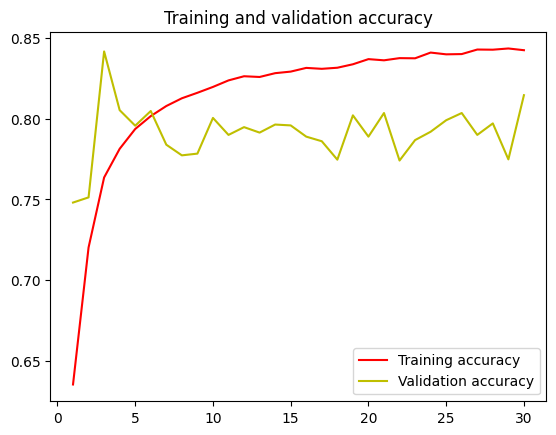

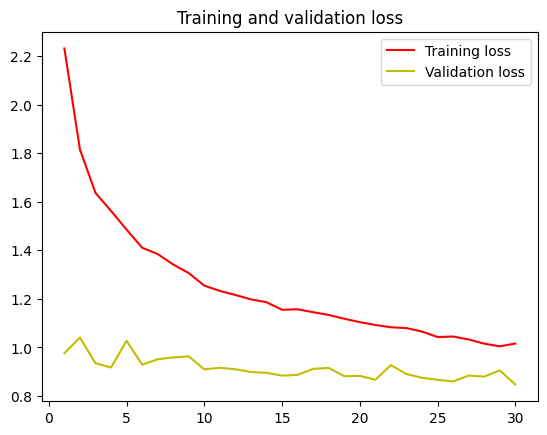

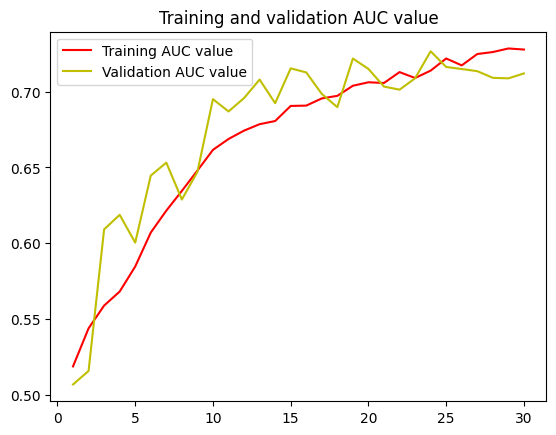

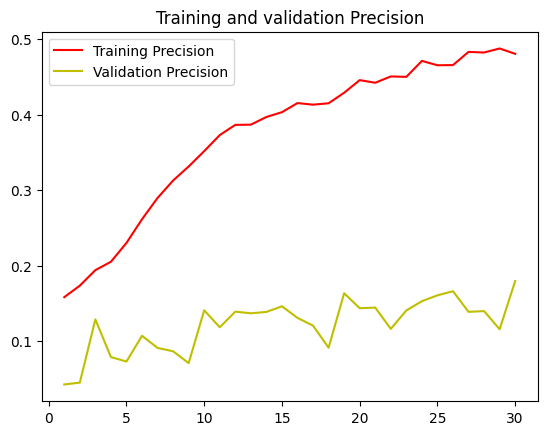

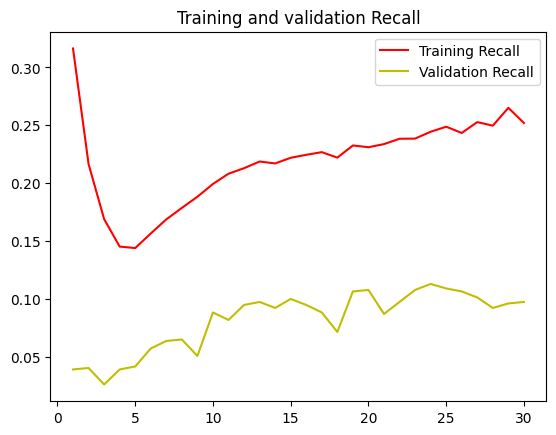

<Figure size 640x480 with 0 Axes>

In [16]:
metrics = [
    ('binary_accuracy', 'accuracy'),
    ('loss', 'loss'),
    ('auc_value', 'AUC value'),
    ('precision', 'Precision'),
    ('recall', 'Recall'),
]
epochs = range(1, len(history.history['loss']) + 1)
for key, label in metrics:
    plt.plot(epochs, history.history[key], 'r', label=f'Training {label}')
    plt.plot(epochs, history.history[f'val_{key}'], 'y', label=f'Validation {label}')
    plt.title(f'Training and validation {label}')
    plt.legend()
    plt.figure()
plt.show()


In [17]:
test_list = sorted(f for f in os.listdir(config.TESTING_SOURCE_PATH) if f.lower().endswith(('.jpg', '.jpeg', '.png')))

print(f"{'File Name':<30} {'Predicted Classes':<30} {'Predicted Labels':<20}")
print(f"Total testing images found: {len(test_list)}")

count_normal = 0
count_single_disease = 0
count_multiple_diseases = 0
count_no_disease = 0

for i in range(len(test_list)):
    source = os.path.join(config.TESTING_SOURCE_PATH, test_list[i])
    img = tf.keras.preprocessing.image.load_img(source, target_size=config.TARGET_SIZE)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    images = np.vstack([img_array])
    predict = model.predict(images)
    predict = predict.reshape(8)
    predicted_labels = (predict >= 0.5).astype(int)

    # Count prediction patterns
    num_pos = np.sum(predicted_labels)
    if num_pos == 0: count_no_disease += 1
    elif num_pos > 1: count_multiple_diseases += 1
    elif predicted_labels[0]: count_normal += 1
    else: count_single_disease += 1

    # labels description
    active_labels = [s for s, p in zip(config.LABELS, predicted_labels) if p] or ["None"]

    # Format and display results
    filename = os.path.basename(source)
    predicted_str = str(predicted_labels)
    labels_str = ', '.join(active_labels)

    print(f"{filename:<30} {labels_str:<30} {predicted_str:<20}")

print(f"\nTest Results Summary:")
print(f"Total Tested: {len(test_list)}")
print(f"Normal: {count_normal} | Single Disease: {count_single_disease} | Multiple Diseases: {count_multiple_diseases} | No Disease Detected: {count_no_disease}")


File Name                      Predicted Classes              Predicted Labels    
Total testing images found: 1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1000_left.jpg                  C                              [0 0 0 1 0 0 0 0]   
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1000_right.jpg                 C                              [0 0 0 1 0 0 0 0]   
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1001_left.jpg                  C                              [0 0 0 1 0 0 0 0]   
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1001_right.jpg                 C                              [0 0 0 1 0 0 0 0]   
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1002_left.jpg                  G, C                           [0 0 1 1 0 0 0 0]   
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1002_right.jpg                 G, C                           [0 0 1 1 0 0 0 0]   
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1003_left.jpg                  G                              [0 0 1 0 0 0 0 0]   
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1